In [1]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

C:\Users\ekru\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\Final_Graph.csv')
print(df.head())

                          Head        Relation           Tail
0       Fluocinolone acetonide  INTERACTS_WITH       Abetimus
1                   Tazarotene  INTERACTS_WITH     Oxybutynin
2                    Guanoclor  INTERACTS_WITH  Nortriptyline
3  Dexamethasone isonicotinate  INTERACTS_WITH    Oxaliplatin
4                 Sparfloxacin  INTERACTS_WITH   Iron sucrose


In [3]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [4]:
print("Train:")
print(train_df)
print("Test:")
print(test_df)
print("Validation:")
print(valid_df)

Train:
                                                   Head         Relation  \
194639                                      Venlafaxine   INTERACTS_WITH   
338072                               Dexmethylphenidate       IN_PRODUCT   
413921                                    Nortriptyline   INTERACTS_WITH   
276174                                      Prenylamine   INTERACTS_WITH   
439150                                   Isosulfan blue   INTERACTS_WITH   
...                                                 ...              ...   
259178                                          Demadex  MANUFACTURED_BY   
365838                                         Restoril        HAS_PRICE   
131932  Discount Drug Mart nausea control Cherry Flavor  MANUFACTURED_BY   
146867                                          AVE9633   INTERACTS_WITH   
121958                                         Doxapram   INTERACTS_WITH   

                                     Tail  
194639                  Magnesium su

In [5]:
#Preprocessing the data

# Strip whitespace from column names and values
for df in [train_df, test_df, valid_df]:
    df.columns = df.columns.str.strip()
    df['Head'] = df['Head'].str.strip()
    df['Tail'] = df['Tail'].str.strip()
    df['Relation'] = df['Relation'].str.strip()

# Map entities and relations to indices
entities = pd.concat([train_df['Head'], train_df['Tail'],
                      test_df['Head'], test_df['Tail'],
                      valid_df['Head'], valid_df['Tail']]).unique()
relations = pd.concat([train_df['Relation'],
                       test_df['Relation'],
                       valid_df['Relation']]).unique()

entity_to_idx = {entity: idx for idx, entity in enumerate(entities)}
relation_to_idx = {relation: idx for idx, relation in enumerate(relations)}

# Function to convert a dataframe to a torch_geometric Data object
def create_graph_data(df):
    edge_index = torch.tensor([
        [entity_to_idx[head] for head in df['Head']],
        [entity_to_idx[tail] for tail in df['Tail']]
    ], dtype=torch.long)
    
    edge_attr = torch.tensor([relation_to_idx[rel] for rel in df['Relation']], dtype=torch.long)
    
    data = Data(edge_index=edge_index, edge_attr=edge_attr)
    data.num_nodes = len(entity_to_idx)
    return data

train_data = create_graph_data(train_df)
valid_data = create_graph_data(valid_df)
test_data  = create_graph_data(test_df)


In [8]:
#Model Creation
class GCN(torch.nn.Module):
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2, dropout=0.3):
        super(GCN, self).__init__()
        
        self.entity_embedding = torch.nn.Embedding(num_entities, hidden_dim)
        
        self.gcn_layers = torch.nn.ModuleList()
        self.gcn_layers.append(GCNConv(hidden_dim, hidden_dim))

        for _ in range(num_layers - 1):
            self.gcn_layers.append(GCNConv(hidden_dim, hidden_dim))
        
        self.dropout = torch.nn.Dropout(dropout)
        self.fc = torch.nn.Linear(hidden_dim * 2, num_relations)
    
    def forward(self, data):
        device = data.edge_index.device
        x = self.entity_embedding(torch.arange(data.num_nodes, device=device))
        
        for gcn in self.gcn_layers:
            x = gcn(x, data.edge_index)
            x = F.relu(x)
            x = self.dropout(x)
        
        head_embeddings = x[data.edge_index[0]]  
        tail_embeddings = x[data.edge_index[1]] 

        edge_features = torch.cat([head_embeddings, tail_embeddings], dim=1)

        out = self.fc(edge_features)
        return F.log_softmax(out, dim=1)

In [9]:
#Training Configuration
hidden_dim = 128
num_layers = 2
dropout = 0.3
learning_rate = 0.001
epochs = 50
patience = 5

num_entities = len(entity_to_idx)
num_relations = len(relation_to_idx)

In [10]:
model = GCN(num_entities, num_relations, hidden_dim,
                 num_layers=num_layers, dropout=dropout)


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

In [11]:
train_losses = []
train_accuracies = []

best_val_loss = float('inf')
patience_counter = 0

In [12]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    output = model(train_data)
    loss = criterion(output, train_data.edge_attr)
    loss.backward()
    optimizer.step()
    
    # Calculate training accuracy
    train_predictions = torch.argmax(output, dim=1)
    correct_predictions = (train_predictions.cpu().numpy() == train_data.edge_attr.cpu().numpy()).sum()
    train_accuracy = correct_predictions / len(train_data.edge_attr)
    
    # Store training loss and accuracy
    train_losses.append(loss.item())
    train_accuracies.append(train_accuracy)
    
    # Evaluate on validation data
    model.eval()
    with torch.no_grad():
        val_output = model(valid_data)
        val_loss = criterion(val_output, valid_data.edge_attr)
    
    scheduler.step()
    
    print(f"Epoch {epoch+1:02d}: Train Loss = {loss.item():.4f}, Train Acc = {train_accuracy:.4f}, Val Loss = {val_loss.item():.4f}")
    
    # Early stopping based on validation loss.
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_model_state)

Epoch 01: Train Loss = 2.5320, Train Acc = 0.0306, Val Loss = 1.9267
Epoch 02: Train Loss = 2.0455, Train Acc = 0.0850, Val Loss = 1.6795
Epoch 03: Train Loss = 1.7464, Train Acc = 0.3318, Val Loss = 1.4903
Epoch 04: Train Loss = 1.4843, Train Acc = 0.6553, Val Loss = 1.3595
Epoch 05: Train Loss = 1.3087, Train Acc = 0.7466, Val Loss = 1.2723
Epoch 06: Train Loss = 1.2766, Train Acc = 0.7600, Val Loss = 1.2139
Epoch 07: Train Loss = 1.2562, Train Acc = 0.7621, Val Loss = 1.1692
Epoch 08: Train Loss = 1.2118, Train Acc = 0.7625, Val Loss = 1.1312
Epoch 09: Train Loss = 1.2114, Train Acc = 0.7610, Val Loss = 1.0948
Epoch 10: Train Loss = 1.1883, Train Acc = 0.7646, Val Loss = 1.0588
Epoch 11: Train Loss = 1.1006, Train Acc = 0.7652, Val Loss = 1.0417
Epoch 12: Train Loss = 1.0657, Train Acc = 0.7708, Val Loss = 1.0257
Epoch 13: Train Loss = 1.1092, Train Acc = 0.7609, Val Loss = 1.0109
Epoch 14: Train Loss = 1.1123, Train Acc = 0.7537, Val Loss = 0.9979
Epoch 15: Train Loss = 1.0644, Tra

<All keys matched successfully>

In [13]:
#Evaluation
model.eval()
with torch.no_grad():
    test_output = model(test_data)
    test_loss = criterion(test_output, test_data.edge_attr)
    test_predictions = torch.argmax(test_output, dim=1)

print(f"\nTest Loss: {test_loss.item():.4f}")

#MR, MRR, Hits @ 1,3,5
def calculate_metrics(output, data):
    ranks = []
    for i in range(output.shape[0]):
        true_relation = data.edge_attr[i].item()
        scores = output[i].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # higher score => lower rank index
        rank = np.where(sorted_indices == true_relation)[0][0] + 1  # 1-indexed
        ranks.append(rank)
    
    ranks = np.array(ranks)
    mrr = np.mean(1.0 / ranks)
    mr = np.mean(ranks)
    hits_at_1 = np.mean(ranks <= 1)
    hits_at_3 = np.mean(ranks <= 3)
    hits_at_5 = np.mean(ranks <= 5)
    return mrr, mr, hits_at_1, hits_at_3, hits_at_5

mrr, mr, hits_at_1, hits_at_3, hits_at_5 = calculate_metrics(test_output, test_data)

print(f"MRR: {mrr:.4f}")
print(f"MR: {mr:.4f}")
print(f"Hits@1: {hits_at_1:.4f}")
print(f"Hits@3: {hits_at_3:.4f}")
print(f"Hits@5: {hits_at_5:.4f}")


Test Loss: 0.8901
MRR: 0.8503
MR: 1.5382
Hits@1: 0.7651
Hits@3: 0.9203
Hits@5: 0.9703


In [14]:

def print_top_k_predictions(output, data, k, num_samples=3):
    indices = random.sample(range(output.shape[0]), num_samples)  # Pick random samples
    for idx in indices:
        true_relation = data.edge_attr[idx].item()
        scores = output[idx].cpu().numpy()
        sorted_indices = np.argsort(-scores)  # Sort in descending order
        top_k = sorted_indices[:k]  

        print(f"\nTest Sample {idx + 1} (True Relation: {relations[true_relation]})")
        for rank, rel_idx in enumerate(top_k, start=1):
            rel_name = relations[rel_idx]
            if rel_idx == true_relation:
                print(f"{rank}. **{rel_name}**  ✅ (Correct)")
            else:
                print(f"{rank}. {rel_name}")

print("\n--- Hits@1 Predictions ---")
print_top_k_predictions(test_output, test_data, k=1, num_samples=3)

print("\n--- Hits@3 Predictions ---")
print_top_k_predictions(test_output, test_data, k=3, num_samples=3)

print("\n--- Hits@5 Predictions ---")
print_top_k_predictions(test_output, test_data, k=5, num_samples=3)


--- Hits@1 Predictions ---

Test Sample 35502 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

Test Sample 60384 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

Test Sample 50526 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)

--- Hits@3 Predictions ---

Test Sample 46443 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. IN_PRODUCT
3. MANUFACTURED_BY

Test Sample 30521 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. AVAILABLE_AT
3. MANUFACTURED_BY

Test Sample 40293 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. IN_PRODUCT
3. MANUFACTURED_BY

--- Hits@5 Predictions ---

Test Sample 12398 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. AVAILABLE_AT
3. MANUFACTURED_BY
4. TREATED_BY
5. IN_PRODUCT

Test Sample 19965 (True Relation: INTERACTS_WITH)
1. **INTERACTS_WITH**  ✅ (Correct)
2. MANUFACTURED_BY
3. IN_PRODUCT
4. AVAILABLE_AT
5. TREATED_BY



In [15]:
# Accuracy,Precision, Recall, F1-score
correct_predictions = (test_predictions.cpu().numpy() == test_data.edge_attr.cpu().numpy()).sum()
accuracy = correct_predictions / len(test_data.edge_attr)
precision = precision_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
recall = recall_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
f1 = f1_score(test_data.edge_attr.cpu().numpy(), test_predictions.cpu().numpy(), average='macro')
print(f"Accuracy: {accuracy:.4f} ({correct_predictions}/{len(test_data.edge_attr)})")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7651 (53598/70053)
Precision: 0.2942
Recall: 0.1539
F1 Score: 0.1444


C:\Users\ekru\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
test_df.to_csv('Results\\GCN_predictions.csv', index=False)

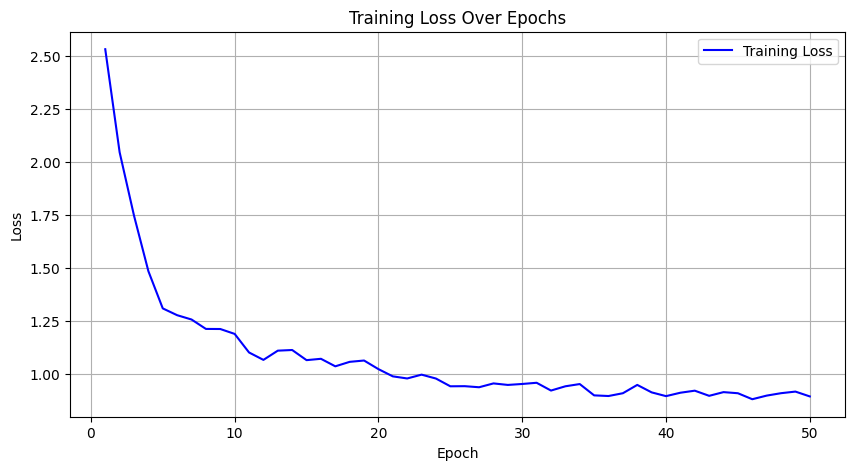

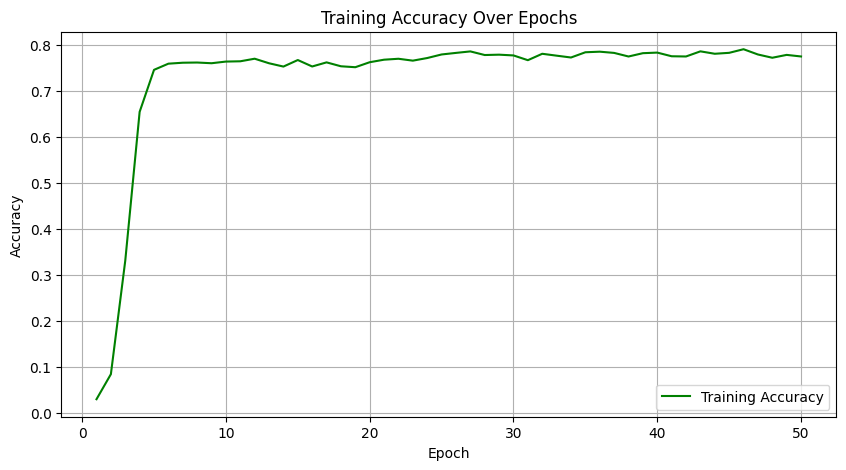

In [17]:
# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()